Feature Importance  - General protective behaviour after mandates - base model  

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib

In [2]:
# downloadig data from the xgboost model code

# general protective behaviour before mandates train set
after_train_general_behav = pd.read_csv("after_train_general_behav.csv")

# remove the target variables and identifiers
drop_cols = ['RecordNo', 'Date','face_mask_scale', 'face_mask_binary','general_protective_behavior_scale',
              'general_protective_behavior_binary','mandate_start_date','7days_rolling_cases',
       '7days_rolling_deaths']


# train set
x_train = after_train_general_behav.drop(columns=drop_cols)
x_train = x_train.astype(float)  # boolean to int

# target variable
y_train = after_train_general_behav["general_protective_behavior_binary"]


# best xgb hyper parameters
best_parameters = joblib.load("general_behav_after_baseModel_XGBoost_bestParameters_rolling.pkl")


In [3]:
best_parameters

{'xgb__learning_rate': 0.1,
 'xgb__max_depth': 5,
 'xgb__min_child_weight': 1,
 'xgb__n_estimators': 100}

100 runs to store all features

In [4]:
# to keep all the importances in each run
all_importances = []


for i in range(100):
    
    temp_xgb = Pipeline([
        ('ros', RandomOverSampler(random_state=i)),
        ('xgb', XGBClassifier(random_state=i,
                              eval_metric='logloss',
                              n_jobs=-1))
        ])

    temp_xgb.set_params(**best_parameters)

    temp_xgb.fit(x_train, y_train)

    all_importances.append(temp_xgb.named_steps['xgb'].feature_importances_)

median - Feature Importance -  For stability

Feature Importance                                      Feature  Importance
6           protective_behavior_nomask_scale    0.571505
19                          state_Queensland    0.030670
23                   state_Western Australia    0.022474
22                            state_Victoria    0.016661
15        Isolate if instructed_Very willing    0.016048
7                                       week    0.012905
17                     state_New South Wales    0.010615
20                     state_South Australia    0.010055
21                            state_Tasmania    0.009498
10                     Isolate if unwell_Yes    0.009291
48         Can't control worrying_Not at all    0.009254
9                 Isolate if unwell_Not sure    0.009057
12  Isolate if instructed_Somewhat unwilling    0.008870
14      Isolate if instructed_Very unwilling    0.008611
26                 employment_status_Retired    0.008231


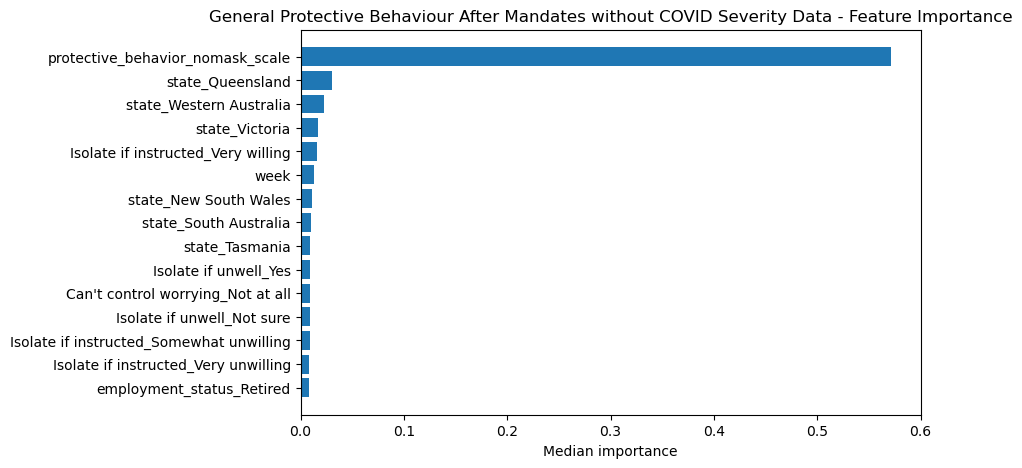

In [5]:
all_importances = np.array(all_importances)

# take the median / mean
median_importance = np.median(all_importances, axis=0) # take the median of each column(feature) 


feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": median_importance
})


feature_importance = feature_importance.sort_values("Importance",ascending=False)

top15 = feature_importance.head(15)

print(f"Feature Importance",top15)
feature_importance.to_csv("general_behav_after_baseModel_XGBoost_FeatureImportance_rolling.csv",index=False)


# plot
plt.figure(figsize=(8,5))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("General Protective Behaviour After Mandates without COVID Severity Data - Feature Importance")
plt.xlabel("Median importance")
plt.gca().invert_yaxis()
plt.savefig("general_behav_after_baseModel_XGBoost_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")
plt.show()
